In [16]:
import json

# Load the Fugu spikes file (200-neuron reference)
with open('../nscale_old/spikes_fugu.json', 'r') as file:
    spikes_fugu = json.load(file)

print(f"Loaded spikes_fugu for {len(spikes_fugu)} neurons")

Loaded spikes_fugu for 200 neurons


In [17]:
# Load 200-neuron mapping
with open('../nscale_old/network_fanin_updated.json', 'r') as file:
    neuron_info = json.load(file)

for i in neuron_info['neuron_dict']:
    del neuron_info['neuron_dict'][i]['fan-in']
    del neuron_info['neuron_dict'][i]['partition_id']

neuron_info = neuron_info['neuron_dict']
print(f"Loaded neuron mapping for {len(neuron_info)} neurons")

Loaded neuron mapping for 200 neurons


In [18]:
import re

# ACT spikes from 200-neuron run
with open('../nscale_old/spikes_act.txt', 'r') as file:
    spike_act = file.read()

spikes_act = {}
mismatches = 0

for i in sorted(spikes_fugu.keys(), key=int):
    core = neuron_info[i]['core']
    neuron = neuron_info[i]['neuron index']

    pattern = r'g\.g\[' + str(core[0]) + '\]\[' + str(core[1]) + '\]\.C\[' + str(core[2]) + '\].*spike neuron id ' + str(neuron) + ' @ (\d+) tick'
    matches = re.findall(pattern, spike_act)
    neuron_spike_time_act = [int(item) for item in matches]
    spikes_act[i] = neuron_spike_time_act

    if neuron_spike_time_act != spikes_fugu[i]:
        mismatches += 1

print(f'Loaded ACT spikes for {len(spikes_act)} neurons')
print(f'ACT vs Fugu mismatches: {mismatches}')

Loaded ACT spikes for 200 neurons
ACT vs Fugu mismatches: 0


/Users/kamerongano/Documents/GitHub/Fugu_dev/fugu/nscale/act_spikes_plot.pdf

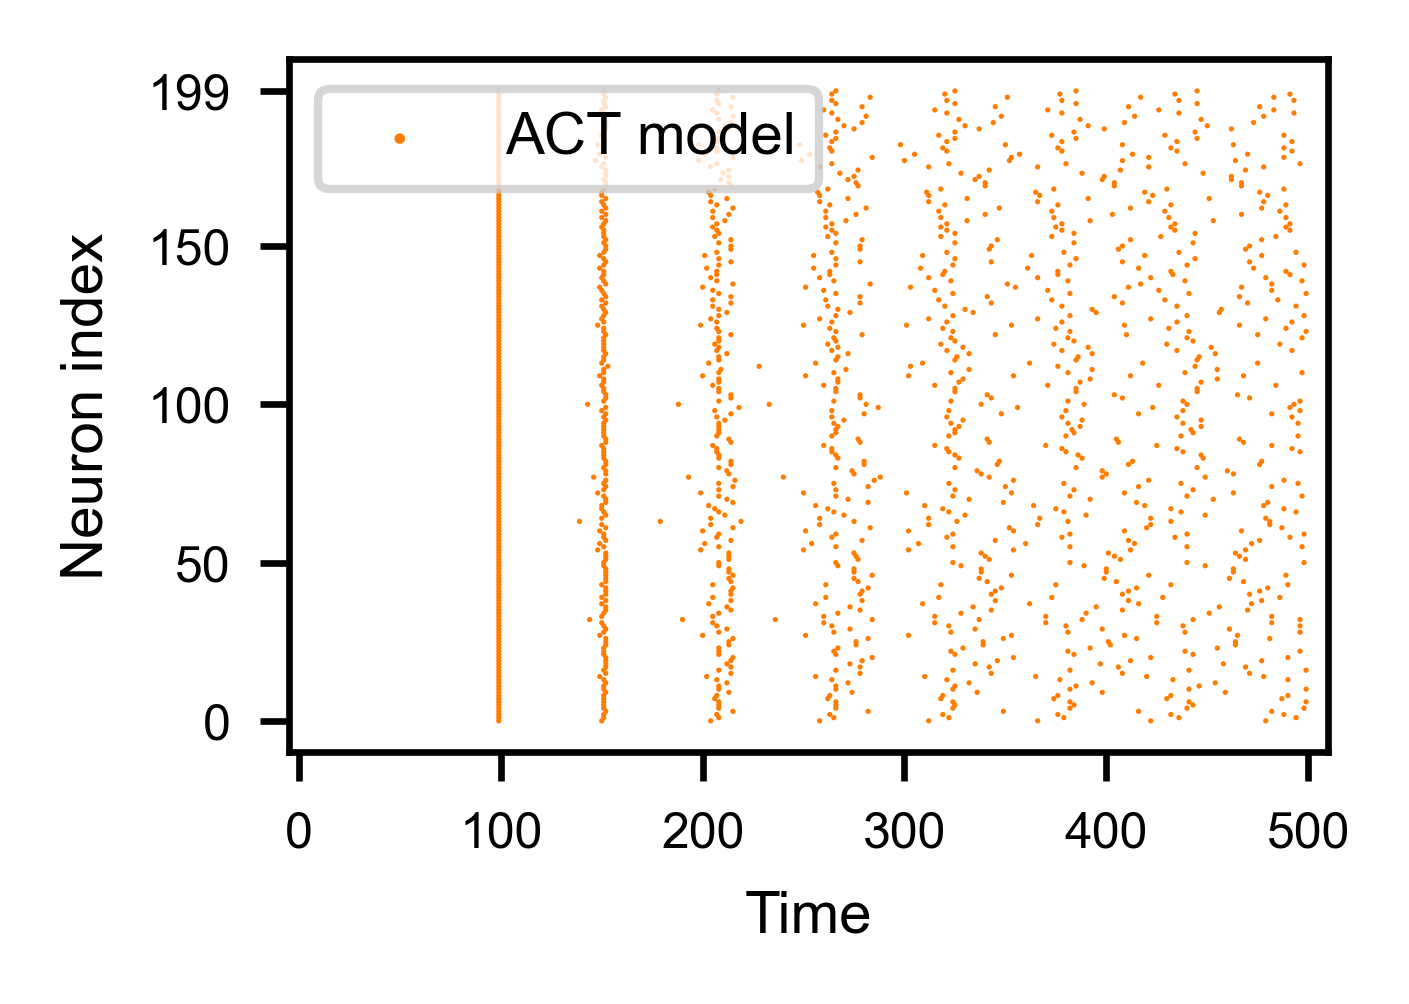

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, FileLink
from matplotlib.path import Path

def left_half_circle_marker(radius=1):
    """Create a left half-circle marker without connecting lines."""
    vertices = []
    for angle in np.linspace(np.pi / 2, 3 * np.pi / 2, num=10):
        vertices.append((radius * np.cos(angle), radius * np.sin(angle)))
    codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 1)
    return Path(vertices, codes)

def right_half_circle_marker(radius=1):
    """Create a right half-circle marker without connecting lines."""
    vertices = []
    for angle in np.linspace(-np.pi / 2, np.pi / 2, num=10):
        vertices.append((radius * np.cos(angle), radius * np.sin(angle)))
    codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 1)
    return Path(vertices, codes)

# Plot formatting matched to recurrent.ipynb
width_inches = ((88) / 2) / 25.4
height_inches = width_inches / 1.5
time = 500

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 7,
    'lines.markersize': 2,
    'figure.dpi': 600,
    'figure.figsize': (width_inches, height_inches),
    'lines.linewidth': 1,
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'savefig.bbox': 'tight',
    'savefig.transparent': True,
    'pdf.fonttype': 42
})

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])

# Keep marker definitions for parity with recurrent.ipynb
left_marker_path = left_half_circle_marker(radius=0.2)
right_marker_path = right_half_circle_marker(radius=0.2)
colors = ['#508CBB', '#Ff7c00', '#78a741']

# Plot all 200 ACT neuron spike trains
for i, neuron in enumerate(sorted(spikes_act.keys(), key=int)):
    times = spikes_act[neuron]
    plt.scatter(times, [i] * len(times), color=to_rgba(colors[1]), s=0.4, marker='o', edgecolors='none', label='ACT model' if i == 0 else "")

plt.xlabel('Time')
plt.ylabel('Neuron index')
selected_indices = [0, 50, 100, 150, 199]
plt.yticks(selected_indices, selected_indices)
plt.xlim(-5, time + 10)
plt.legend(prop={'family': 'Arial'}, loc='upper left', markerscale=2)
plt.grid(False)

with PdfPages('act_spikes_plot.pdf') as pdf:
    pdf.savefig(bbox_inches='tight')

display(FileLink('act_spikes_plot.pdf'))

/Users/kamerongano/Documents/GitHub/Fugu_dev/fugu/nscale/act_fugu_overlay_plot.pdf

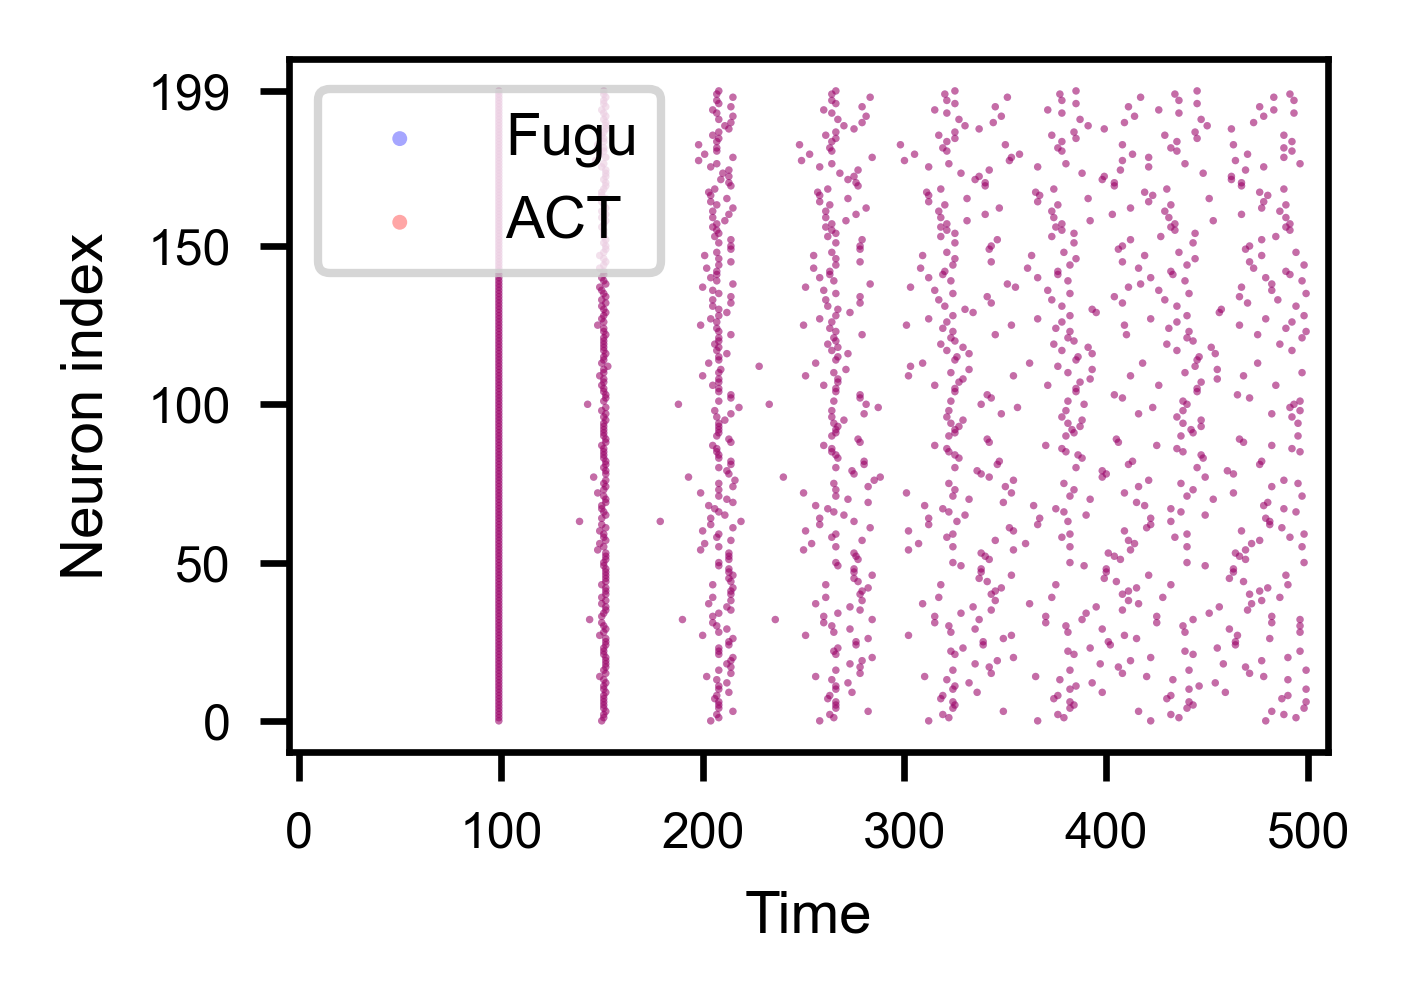

In [20]:
# Overlay plot: Fugu (blue) + ACT (red) with transparency
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])

for i, neuron in enumerate(sorted(spikes_fugu.keys(), key=int)):
    times_fugu = spikes_fugu[neuron]
    times_act = spikes_act.get(neuron, [])

    # Blue translucent dots for Fugu
    plt.scatter(
        times_fugu, [i] * len(times_fugu),
        color='blue', alpha=0.35, s=0.8, marker='o', edgecolors='none',
        label='Fugu' if i == 0 else ""
    )

    # Red translucent dots for ACT
    plt.scatter(
        times_act, [i] * len(times_act),
        color='red', alpha=0.35, s=0.8, marker='o', edgecolors='none',
        label='ACT' if i == 0 else ""
    )

plt.xlabel('Time')
plt.ylabel('Neuron index')
selected_indices = [0, 50, 100, 150, 199]
plt.yticks(selected_indices, selected_indices)
plt.xlim(-5, time + 10)
plt.legend(prop={'family': 'Arial'}, loc='upper left', markerscale=2)
plt.grid(False)

with PdfPages('act_fugu_overlay_plot.pdf') as pdf:
    pdf.savefig(bbox_inches='tight')

display(FileLink('act_fugu_overlay_plot.pdf'))